# Set Up

## Libraries

In [1]:
import sys
sys.path.append(r"C:\GitHubRepos\APSIMTools\GraphLib")

%load_ext autoreload
%autoreload 2

from dataclasses import dataclass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sqlite3
import subprocess
import shutil
import warnings
from matplotlib.lines import Line2D
from pandas.api.types import is_numeric_dtype


# graph models
from apsim_tools.graphing import (
    plot_obs_pred_by_branch,
    plot_stage_timeseries,
    compute_stats
)

from apsim_tools.style import ( 
    Colors, 
    Markers,
    Lines
)

from apsim_tools.runner import (
reset_repo,
checkout_branch,
build_apsim,
run_apsim
)



## Grouping functions

In [2]:
def value_at_stage(target, tol_low, tol_high):

    def fn(df, variable):

        window = df.loc[
            (df["Lentil.Phenology.Stage"] > tol_low) &
            (df["Lentil.Phenology.Stage"] < tol_high)
        ]

        window = window[window[variable].notna()]

        if window.empty:
            return np.nan

        idx = (
            window["Lentil.Phenology.Stage"]
            .sub(target)
            .abs()
            .idxmin()
        )

        return window.loc[idx, variable]

    return fn

def MeanValue(df, variable):
    return df[variable].mean()

def SumValues(df, variable):
    return df[variable].sum()

## data class

In [3]:
@dataclass
class AnalysisData:

    pred: pd.DataFrame
    obs: pd.DataFrame
    harvest_pred: pd.DataFrame
    harvest_obs: pd.DataFrame

    def derive(self, name, fn):

        derived = fn(self.obs)
    
        if not isinstance(derived, pd.Series):
            derived = pd.Series(
                derived,
                index=self.obs.index)
    
        if name in self.obs.columns:
            self.obs[name] = (
                self.obs[name]
                .combine_first(derived))
    
        else:
            self.obs[name] = derived

    def filter(self, fn):

        filterMask = fn(self.obs)

        return filterMask

    def fill_triangular_set(self, top, left, right):

        cols = [top, left, right]
    
        missing = [c for c in cols if c not in self.obs.columns]
    
        if missing:
            print(f"Missing columns: {missing}")
            return self
    
        a = self.obs[top]
        b = self.obs[left]
        c = self.obs[right]
    
        # fill top
        self.obs[top] = a.combine_first(b * c)
    
        # fill left
        self.obs[left] = b.combine_first(
            a.div(c.replace(0, np.nan))
        )
    
        # fill right
        self.obs[right] = c.combine_first(
            a.div(b.replace(0, np.nan))
        )
        
    def aggregate_sim_values(self, var, outName, source="obs", fn = MeanValue, filter_fn = None):
        df = getattr(self, source)
        mask = pd.Series(True, index=df.index)
        if filter_fn:
            mask = filter_fn(df)
    
        grouped = (df.loc[mask].groupby("Simulation.Name"))
    
        values = grouped.apply(lambda g: fn(g, var))
    
        self.obs[outName] = (self.obs["Simulation.Name"].map(values))        

    def summary(self):
        print(f"Pred rows : {len(self.pred):,}")
        print(f"Obs rows  : {len(self.obs):,}")

        print(f"Pred sims : {self.pred['SimulationID'].nunique():,}")
        print(f"Obs sims  : {self.obs['SimulationID'].nunique():,}")


ANALYSIS_KEYS = [
    "file",
    "SimulationID",
    "Clock.Today"
]

## Load branch data function

In [4]:
def load_branch_data(config, apply_fn):
    pred_frames = []
    obs_frames = []
    for branch_name, git_branch in config["git_branches"].items():
        
        if branch_name in config['run_branches']:
            reset_repo(config)
            checkout_branch(git_branch, config)
            build_apsim(config)
    
        for sim in config["sim_files"]:
    
            db = sim.parent / f"{sim.stem}_{branch_name}.db"
    
            # --- Run APSIM ---
            if branch_name in config['run_branches']:
                print("")
                print(f"▶ Running APSIM [{branch_name}]: {sim.name}")
                run_apsim(sim, config, apply_fn)
    
                original_db = sim.with_suffix(".db")
                hold_db = sim.parent / f"{sim.stem}_{branch_name}.db"
    
                shutil.copyfile(original_db, hold_db)
    
            if not db.exists():
                print(f"❌ DB not created: {db}")
                continue
    
            # ======================================================
            # ✅ READ DATABASE
            # ======================================================
            with sqlite3.connect(db) as conn:
    
                tables = pd.read_sql(
                    "SELECT name FROM sqlite_master WHERE type='table';",
                    conn
                )["name"].tolist()
    
                print(f"{sim.name} tables: {tables}")
    
                # ---------------------------------------------
                # ✅ Observed
                # ---------------------------------------------
                obs = None
                if config["obs_table_name"] in tables and branch_name=="master":
                    obs = pd.read_sql(f"SELECT * FROM [{config['obs_table_name']}]", conn)
                    obs = obs.drop(columns=["SimulationName"], errors="ignore")
                    
                # ---------------------------------------------
                # ✅ Predictions
                # ---------------------------------------------
                pred = None
                if config["pred_table_name"] in tables:
                    pred = pd.read_sql(f"SELECT * FROM [{config['pred_table_name']}]", conn)
                    
                if pred is None and obs is None:
                    continue
                
                # ---------------------------------------------
                # ✅ Diagnose SimulationID alignment
                # ---------------------------------------------
                if pred is not None and obs is not None:
    
                    pred_ids = set(pred["SimulationID"].dropna().unique())
                    obs_ids = set(obs["SimulationID"].dropna().unique())
    
                    # --- Diagnostics (optional but useful) ---
                    missing_ids = pred_ids - obs_ids
                    if missing_ids:
                        print(f"\n⚠️ Missing observed simulations in {sim.name}: {len(missing_ids)}")
    
                    extra_obs_ids = obs_ids - pred_ids
                    if extra_obs_ids:
                        print(f"\n⚠️ Dropping unmatched observed simulations in {sim.name}: {len(extra_obs_ids)}")
    
                # ---------------------------------------------
                # ✅ Attach metadata (branch, file)
                # ---------------------------------------------
                if pred is not None:
                    pred["file"] = sim.name
                    pred["branch"] = branch_name
                    pred_frames.append(pred)
                    if "Clock.Today" in pred.columns:
                        pred["Clock.Today"] = pd.to_datetime(pred["Clock.Today"])
    
                if obs is not None:
                    obs["file"] = sim.name
                    obs_frames.append(obs)
                    obs["branch"] = branch_name
                    if "Clock.Today" in obs.columns:
                        obs["Clock.Today"] = pd.to_datetime(obs["Clock.Today"])
    
        if not obs_frames:
            raise RuntimeError(f"No obs data loaded")
        if not pred_frames:
            raise RuntimeError(f"No pred data loaded")
    return AnalysisData(
                        pred=pd.concat(pred_frames, ignore_index=True),
                        obs=pd.concat(obs_frames, ignore_index=True),
                        harvest_pred = pd.DataFrame,
                        harvest_obs = pd.DataFrame
                        )

# Read in data

## Set branch and file data

In [5]:
REPO_PATH = Path(r"C:\GitHubRepos\ApsimX")

SIM_FILES = [
    #Path(REPO_PATH) / 'Prototypes/Lentil/Lentil.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/FAHMA/FAHMA_Lentil.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2019_NSW_Greenethorpe_Mixed_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_Vic_Kalkee_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_SA_Riverton_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_Methul_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_Vic_Ouyen_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_RankinsSprings_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_SA_Pinery_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Vic_Dooen_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Vic_Ouyen_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Qld_Gatton_Mixed_Light.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_NSW_Greenethorpe_Mixed_NFix.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_Vic_Walpeup_Lentil_Satellite.apsimx'
]


CONFIG = {
    "git_branches":  {'master':"Lentil_Model_NaPA"},
    "run_branches": [],#['master'],
    "sim_files": SIM_FILES,
    "repo_path": Path(r"C:\GitHubRepos\ApsimX"),
    "apsim_exe": r"C:\GitHubRepos\ApsimX\bin\Release\net8.0\Models.exe",
    "apsim_solution": r"C:\GitHubRepos\ApsimX\ApsimX.sln",
    "obs_table_name": "Observed",
    "pred_table_name": "AnalysisReport"
}

## Write apply file

In [6]:
# this function writes and apply file that the CLI
def write_apply_file(sim_file):
    """
    Create an APSIM CLI apply file which:
    - removes specified reports
    - injects AnalysisReport
    - sets variables
    - saves and runs simulation
    """
    report_library = r"C:\GitHubRepos\APSIMTools\Lentil analysis\Report_lib.apsimx"
    apply_file = sim_file.with_name(f"_apply_{sim_file.stem}.txt")

    lines = []

    # ---------------------------------------------
    # Add AnalysisReport to all Simulation nodes
    # ---------------------------------------------
    lines.append("delete all [Report]")
    lines.append("delete all [Report]")
    lines.append(f"add [AnalysisReport] from {report_library} to all [Zone]")

    # ---------------------------------------------
    # Remove existing ObsPred table and add HarvestObsPred to data store
    # ---------------------------------------------
    lines.append("delete all [PredictedObserved]")
    lines.append("delete all [PredictedObserved]")
    
    # ---------------------------------------------
    # Save + run
    # ---------------------------------------------
    lines.append(f"save {sim_file}")
    lines.append(f"run")

    # Write file
    apply_file.write_text("\n".join(lines))

    return apply_file

## Read in data

In [7]:
data = load_branch_data(CONFIG, write_apply_file)

FAHMA_Lentil.apsimx tables: ['_Factors', '_InitialConditions', '_Messages', 'HarvestReport', '_Simulations', '_Checkpoints', 'HarvestObsPred', '_PredictedObserved', 'AnalysisReport', '_Units', 'DailyObsPred', 'Observed']
2019_NSW_Greenethorpe_Mixed_Detailed.apsimx tables: ['_Factors', '_InitialConditions', 'DailyReport', '_Messages', 'HarvestReport', '_Simulations', '_Checkpoints', '_Units', '_PredictedObserved', 'AnalysisReport', 'Observed']

⚠️ Missing observed simulations in 2019_NSW_Greenethorpe_Mixed_Detailed.apsimx: 9

⚠️ Dropping unmatched observed simulations in 2019_NSW_Greenethorpe_Mixed_Detailed.apsimx: 180
2022_Vic_Kalkee_Lentil_Detailed.apsimx tables: ['_Factors', '_InitialConditions', '_Messages', 'HarvestReport', '_Simulations', '_Checkpoints', 'HarvestObsPred', '_PredictedObserved', 'AnalysisReport', '_Units', 'DailyObsPred', 'Observed']

⚠️ Dropping unmatched observed simulations in 2022_Vic_Kalkee_Lentil_Detailed.apsimx: 172
2022_SA_Riverton_Lentil_Detailed.apsimx tab

# Tidy up observed data frame

## deal with unuseful and duplicate columns

In [8]:
def drop_unused_cols(data):
    Keep_columns = [
    'SimulationID',
    'Clock.Today',
    'Lentil.Phenology.CurrentStageName',
    'Lentil.Phenology.Stage',
    'Lentil.Phenology.EmergenceDAS',
    'Lentil.Phenology.MaturityDAS',
    'Lentil.Phenology.StartFloweringDAS',
    'Lentil.Phenology.StartPoddingDAS',
    'Lentil.AboveGround.Wt',
    'Lentil.Stem.Wt',
    'Lentil.Fruit.Wt',
    'Lentil.Pod.Wt',
    'Lentil.Leaf.Wt',
    'Lentil.Leaf.Canopy.SpecificArea',
    'Lentil.Grain.Wt',
    'Lentil.Grain.Number',
    'Lentil.Grain.Size',
    'Lentil.Grain.HarvestIndex',
    'Lentil.Leaf.Canopy.CoverTotal',
    'Lentil.SowingData.Cultivar',
    'file',
    'branch',
    'Lentil.Phenology.StartBuddingDAS',
    'Lentil.Leaf.NodeNumber',
    'Lentil.AboveGround.N',
    'Lentil.Pod.Number',
    'Lentil.Pod.GrainNumber',
    'Lentil.SowingData.Population']
    
    data.obs = data.obs.loc[:,Keep_columns].copy()

    remove_cols = [
    'branch',
    'file',
    'SimulationID',
    'Clock.Today',
    'Lentil.Phenology.CurrentStageName',
    ]
    
    numeric_cols = [
        c for c in Keep_columns
        if c not in remove_cols
    ]
    for c in numeric_cols:
        data.obs[c] = pd.to_numeric(data.obs[c], errors="coerce")
    return data

data = drop_unused_cols(data)

## Tidy up indexing in observed file

In [9]:
def fill_obs_metadata(data):

    cols = [
        "Experiment",
        "Simulation.Name",
        "Lentil.SowingData.Cultivar",
        "Lentil.Population",
        "IWeather.Latitude",
        "IWeather.Longitude"
    ]

    keys = ["file", "SimulationID"]

    meta = (
        data.pred
        [keys + cols]
        .drop_duplicates()
    )

    data.obs = (
        data.obs
        .drop(columns=cols, errors="ignore")
        .merge(meta, on=keys, how="left")
    )

    return data

data = fill_obs_metadata(data)

## add in custom indexing

In [10]:
# Specifiy map for cultivars to winter or spring type
project_group={
 'Caragabal19':'Historic',
 'Emerald19':'Historic',
 'Gatton19':'Historic',
 'Greenethorpe19':'Historic',
 'GreenethorpePhen19':'Historic',
 'Mildura19':'Historic',
 'Millmerran19':'Historic',
 'Walgett19':'Historic',
 'Wellcamp25':'FAHMA',
 'Roberts1988':'ContEnv',
 'Roberts1986':'ContEnv',
 'Summerfield1985':'ContEnv',
 'Rajandran2022':'ContEnv',
 'Dooen2001':'Historic',
 'Roseworthy':'Historic',
 'Gatton24':'FAHMA',
 'Gatton23':'FAHMA',
 'ForestHill25':'FAHMA',
 '2019_NSW_Greenethorpe_Mixed_Detailed':'NaPA',
 '2022_Vic_Kalkee_Lentil_Detailed':'NaPA',
 '2022_SA_Riverton_Lentil_Detailed':'NaPA',
 '2022_NSW_WaggaWagga_Lentil_Detailed':'NaPA',
 '2022_NSW_Methul_Lentil_Satellite':'NaPA',
 '2022_Vic_Ouyen_Lentil_Satellite':'NaPA',
 '2022_NSW_RankinsSprings_Lentil_Satellite':'NaPA',
 '2022_SA_Warnertown_Lentil_Satellite':'NaPA',
 '2023_SA_Pinery_Lentil_Detailed':'NaPA',
 '2023_Vic_Dooen_Lentil_Detailed':'NaPA',
 '2023_SA_Warnertown_Lentil_Satellite':'NaPA',
 '2023_Vic_Ouyen_Lentil_Satellite':'NaPA',
 '2023_Qld_Gatton_Mixed_Light':'NaPA',
 '2024_NSW_Greenethorpe_Mixed_NFix':'NaPA',
 '2024_SA_Warnertown_Lentil_Satellite':'NaPA',
 '2024_Vic_Walpeup_Lentil_Satellite':'NaPA',
}

WaterIndex = pd.read_pickle('IrrigIndex')
sim_water_map = dict(zip(WaterIndex["SimulationName"], WaterIndex["WaterGroup"]))

# Pack maps together ready to be inserted as indexes 
additional_index_maps = {
    "ProjectGroup": {
        "source": "Experiment",
        "map": project_group
    },
    "WaterTrt": {
        "source": "Simulation.Name",
        "map": sim_water_map
    }
}

In [11]:
def add_index_maps(data, additional_index_maps):

    for new_col, spec in additional_index_maps.items():

        source_col = spec["source"]
        mapping = spec["map"]

        if source_col not in data.obs.columns:
            print(
                f"Warning: '{source_col}' not found "
                f"for index '{new_col}'"
            )
            continue

        data.obs[new_col] = (
            data.obs[source_col]
            .map(mapping)
        )
        
        data.pred[new_col] = (
            data.pred[source_col]
            .map(mapping)
        )
    return data

data = add_index_maps(data, additional_index_maps)

# Derive additional data

## Agregate variables

In [12]:
# data.derive('Wheat.Leaf.Wt',
#                 lambda df:
#             df["Wheat.Leaf.Live.Wt"] +
#             df["Wheat.Leaf.Dead.Wt"])

## Complete traingular sets

The variable at the top of the triangle is derived as to product of the two variables at the bottom.
The variables at the bottom are derived as the top variable divided the the other bottom variable 
        A
       / \
      /   \
     B  x  C

A = B * C

B = A / C

C = A / B

In [13]:
# data.fill_triangular_set('Wheat.Spike.N',
#                             'Wheat.Spike.Wt',
#                             'Wheat.Spike.NConc')

# Set harvest data frames

In [14]:
data.harvest_obs = data.obs.loc[data.obs['Lentil.Phenology.CurrentStageName']=="HarvestRipe",:]
data.harvest_pred = data.pred.loc[data.pred['Lentil.Phenology.CurrentStageName']=="HarvestRipe",:]

# Set blank stats results frame

In [15]:
stats_template = {
    'NSE': np.nan,
    'Bias': np.nan,
    'RMSE': np.nan,
    'R2': np.nan
}

stats_results = pd.DataFrame(
    columns=stats_template.keys(),
    index=pd.MultiIndex(
        levels=[[], []],
        codes=[[], []],
        names=['var', 'branch']
    )
)

# Graphing

In [16]:
DistinctColors = {
     1: "#000000",  # Black
     2: "#E41A1C",  # Red
     3: "#377EB8",  # Blue
     4: "#4DAF4A",  # Green
     5: "#FF7F00",  # Orange
     6: "#984EA3",  # Purple
     7: "#A65628",  # Brown
     8: "#F781BF",  # Pink
     9: "#17BECF",  # Cyan
    10: "#BCBD22",  # Olive
    11: "#1B9E77",  # Teal
    12: "#D95F02",  # Dark Orange
    13: "#E7298A"   # magenta
}
    
def build_style_maps(index):
    colour_ids = sorted(DistinctColors.keys())
    marker_ids = sorted(Markers.keys())

    colour_map = {}
    marker_map = {}

    for i, ind in enumerate(index):
        c_id = colour_ids[i % len(colour_ids)]
        m_id = marker_ids[(i // len(colour_ids)) % len(marker_ids)]

        colour_map[ind] = DistinctColors[c_id]
        marker_map[ind] = Markers[m_id]

    return colour_map, marker_map

In [17]:
def get_obs_pred_pair(plot_branch, var, mode = '', demark_by = None, filter_dict = None):
    index_vars = ['branch',
                  'Simulation.Name'] 
    if demark_by is not None:
        index_vars.append(demark_by)

    if filter_dict:
        index_vars += filter_dict['filter_vars']
        
    if mode == 'harvest':
        #index_vars.append('Lentil.Phenology.CurrentStageName')
        group_vars = ['Simulation.Name']
        master_obs = data.harvest_obs[index_vars + [var]]
        branch_pred = data.harvest_pred.loc[data.harvest_pred.branch == plot_branch,index_vars+[var]]
    else:
        index_vars.append('Clock.Today')
        group_vars = ['Simulation.Name','Clock.Today']
        master_obs = data.obs[index_vars + [var]]
        branch_pred = data.pred.loc[data.pred.branch == plot_branch, index_vars + [var]]

    agg_dict = {
        col: 'first'
        for col in index_vars
        if col not in group_vars
    }
    agg_dict[var] = 'mean'

    if filter_dict:
        Mask = filter_dict["filter_fn"](master_obs)
        master_obs = master_obs.loc[Mask,:]
    
    master_obs_means = master_obs.groupby(group_vars, as_index=False).agg(agg_dict).dropna(subset=[var])
    master_obs_means.set_index(group_vars,inplace=True)
        
    if filter_dict:
        Mask = filter_dict["filter_fn"](branch_pred)
        branch_pred = branch_pred.loc[Mask, :]

    branch_pred_means = branch_pred.groupby(group_vars, as_index=False).agg(agg_dict).dropna(subset=[var])
    branch_pred_means.set_index(group_vars,inplace=True)
    
    obs_pred_pair = branch_pred_means.reindex(master_obs_means.index).rename(columns={var: "pred"}) 
    obs_pred_pair["obs"] = master_obs_means[var]

    return obs_pred_pair

In [18]:
def plot_branch_obs_pred(var, obs_pred_pair, ax = None, demark_by=None):
    if ax is None:
        fig, ax = plt.subplots()

    if demark_by:
        demarkers = obs_pred_pair[demark_by].drop_duplicates().to_list()
        colors, markers = build_style_maps(demarkers)
    groups = markers.keys()
    for g in groups:
        groupData = obs_pred_pair.loc[obs_pred_pair[demark_by] == g, :]
        marker = markers[g]
        color_seq = groupData[demark_by].map(colors)
        ax.scatter(groupData['obs'],
           groupData['pred'],
           s=40,
           c=colors[g],
           marker=marker,
           label=g)

    return ax

In [19]:
def plot_obs_pred_by_branch(var, demark_by=None, filter_dict = None, mode = '',
                            leg=True, leg_ncols = 2):
    fig, axes = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(5, 5),
        constrained_layout=True
    )
   
    branches = CONFIG["git_branches"].keys()
    ncols = len(branches)
    
    axes = np.array(axes).flatten()
    
    bpos = 1
    ax_max = 0
    for ax, plot_branch in zip(axes, branches):
    
        obs_pred_pair = get_obs_pred_pair(plot_branch, var,mode = mode, demark_by=demark_by, filter_dict = filter_dict)
    
        plot_branch_obs_pred(var, obs_pred_pair, ax, demark_by)

        ax_max = max(ax_max,max(obs_pred_pair.loc[:,'pred'].max(),obs_pred_pair.loc[:,'obs'].max()))

        stats = compute_stats(obs_pred_pair)
        n = len(obs_pred_pair['obs'].dropna())

        stats_results.loc[(var, plot_branch), :] = stats
        

        stats_text = (
                f"{plot_branch}\n"
                f"n = {n}\n" 
                f"NSE = {stats['NSE']:.2f}\n"
                f"Bias = {stats['Bias']:.2f}"
            )
        ax.text(0.05,0.98,stats_text,
                transform=ax.transAxes,
               ha="left",
               va="top",
               fontsize=10,
               bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
               )
        if bpos == 1:
            ax.set_ylabel(f"Predicted {var}")

        ax.set_xlabel(f"Observed {var}")
        bpos+=1

    for ax, plot_branch in zip(axes, branches):
        ax.plot([0,ax_max],[0,ax_max],'--',color='k')

    if leg == True:
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0), ncol=leg_ncols)
    

# Phenology

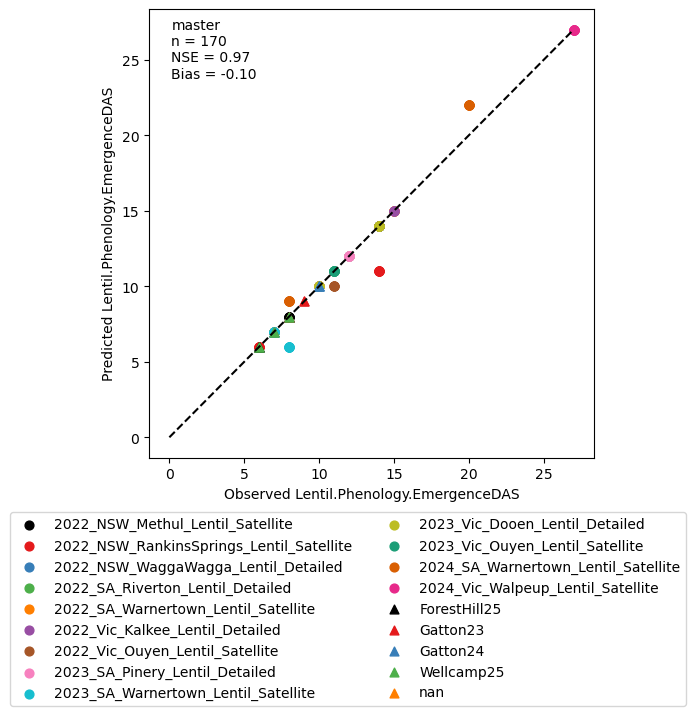

In [20]:
plot_obs_pred_by_branch("Lentil.Phenology.EmergenceDAS",demark_by='Experiment',mode='harvest',
                       leg=True, leg_ncols = 2)

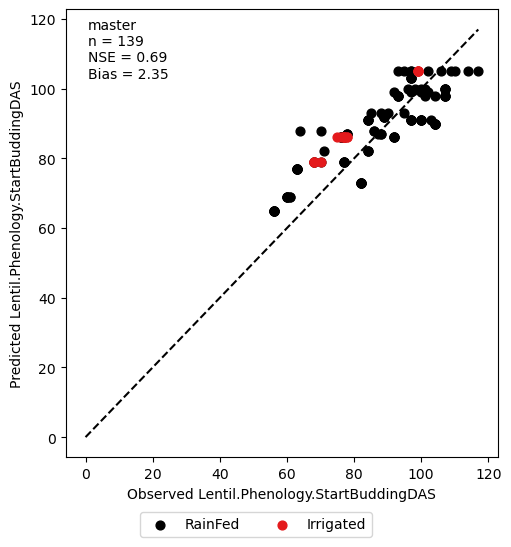

In [21]:
plot_obs_pred_by_branch("Lentil.Phenology.StartBuddingDAS",demark_by='WaterTrt',mode='harvest',
                       leg=True, leg_ncols = 2)

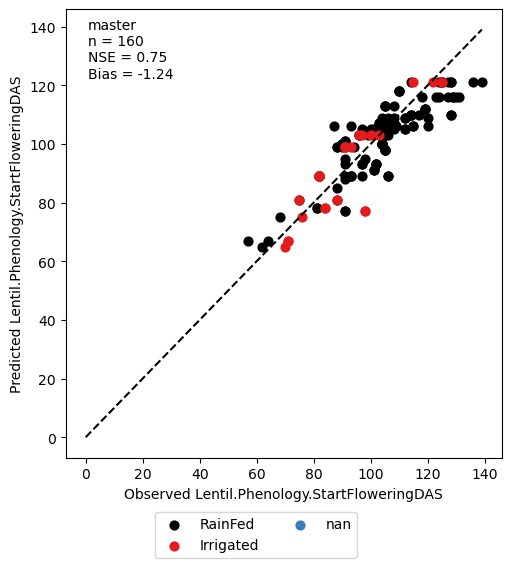

In [22]:
plot_obs_pred_by_branch("Lentil.Phenology.StartFloweringDAS",demark_by='WaterTrt',mode='harvest',
                       leg=True, leg_ncols = 2)

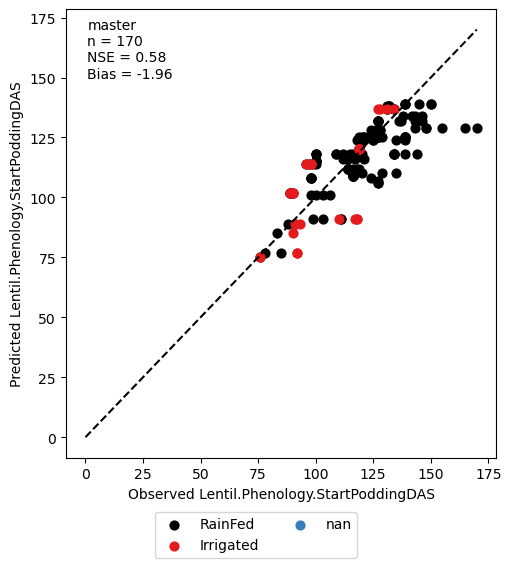

In [23]:
plot_obs_pred_by_branch("Lentil.Phenology.StartPoddingDAS",demark_by='WaterTrt',mode='harvest',
                       leg=True, leg_ncols = 2)

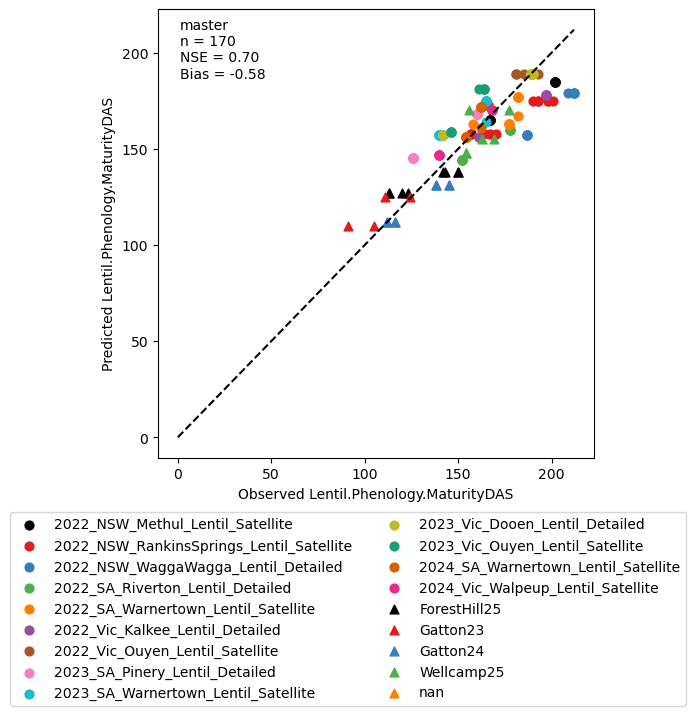

In [24]:
plot_obs_pred_by_branch("Lentil.Phenology.MaturityDAS",demark_by='Experiment',mode='harvest',
                       leg=True, leg_ncols = 2)

# Harvest

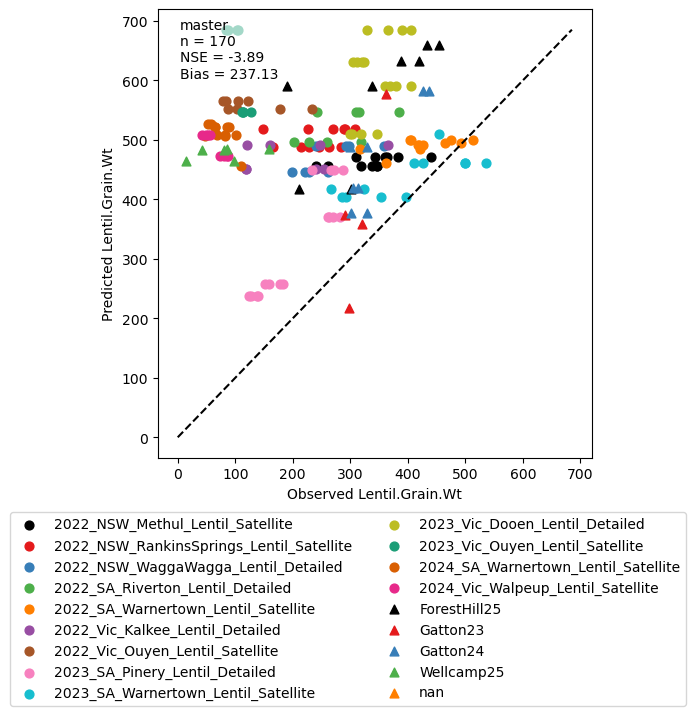

In [25]:
plot_obs_pred_by_branch("Lentil.Grain.Wt",demark_by='Experiment',mode='harvest',
                       leg=True, leg_ncols = 2)

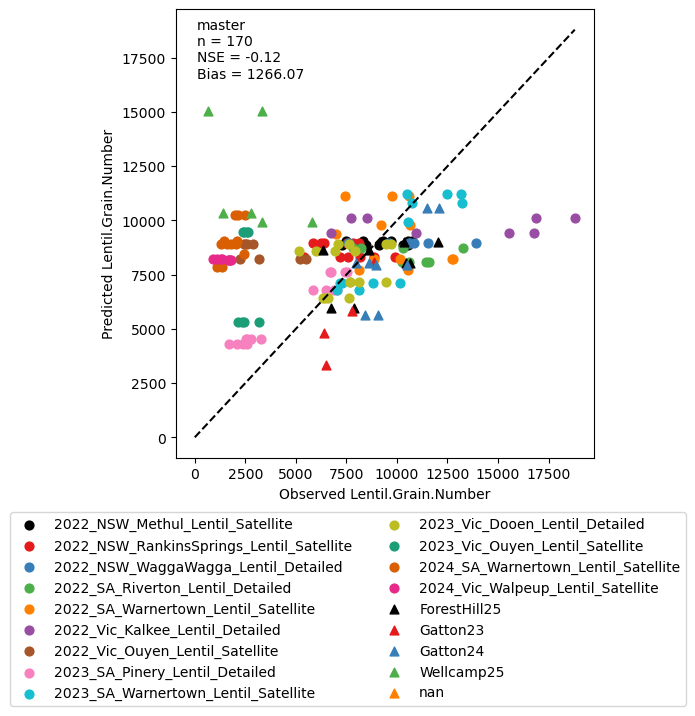

In [26]:
plot_obs_pred_by_branch("Lentil.Grain.Number",demark_by='Experiment',mode='harvest',
                       leg=True, leg_ncols = 2)

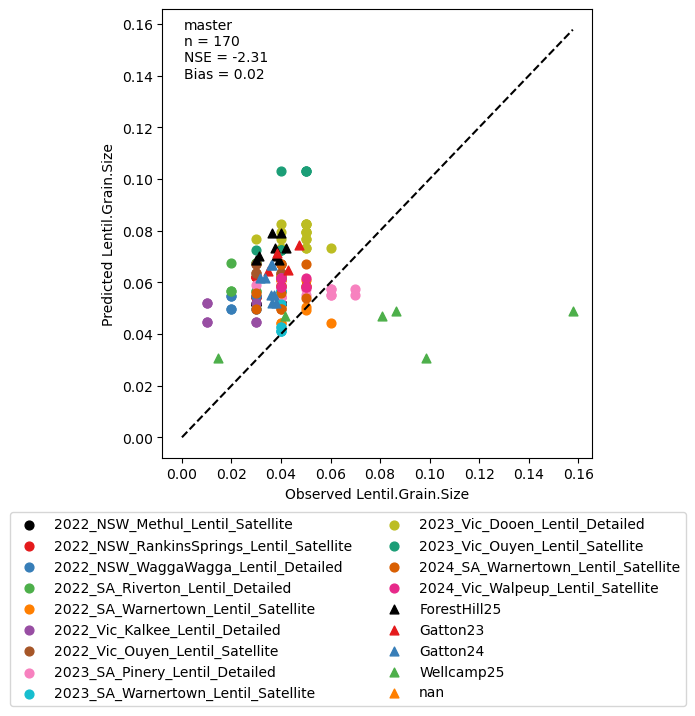

In [27]:
plot_obs_pred_by_branch("Lentil.Grain.Size",demark_by='Experiment',mode='harvest',
                       leg=True, leg_ncols = 2)

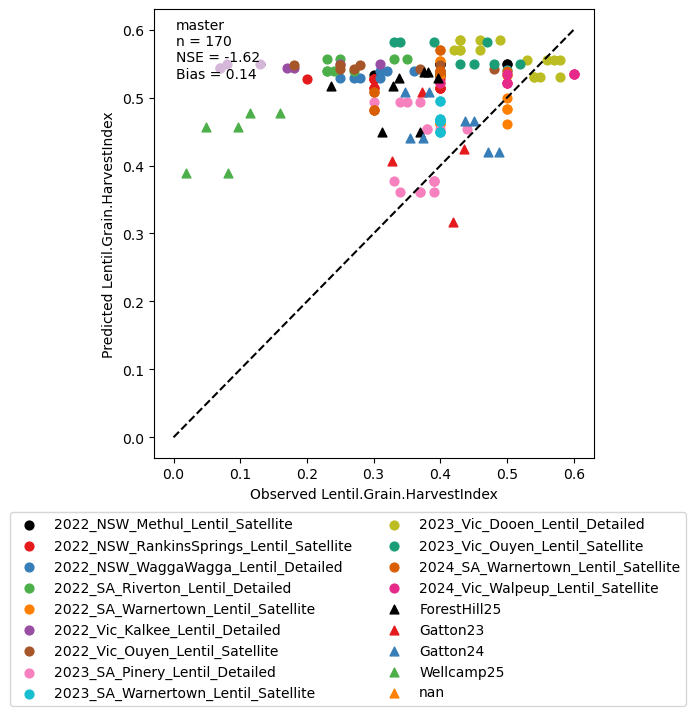

In [28]:
plot_obs_pred_by_branch("Lentil.Grain.HarvestIndex",demark_by='Experiment',mode='harvest',
                       leg=True, leg_ncols = 2)

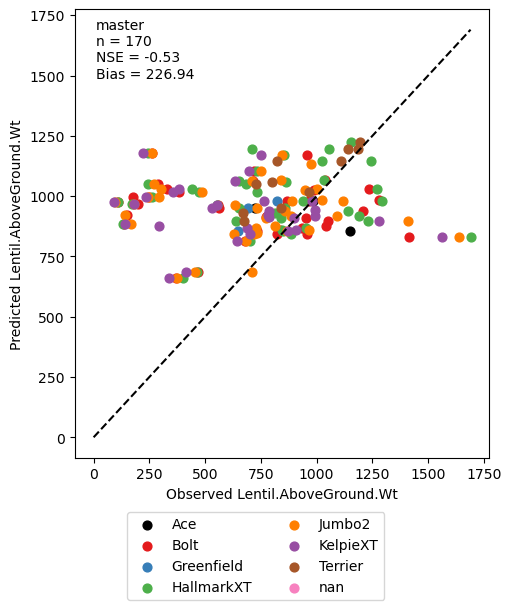

In [29]:
plot_obs_pred_by_branch("Lentil.AboveGround.Wt",demark_by='Lentil.SowingData.Cultivar',mode='harvest',
                       leg=True, leg_ncols = 2)

# Node Number

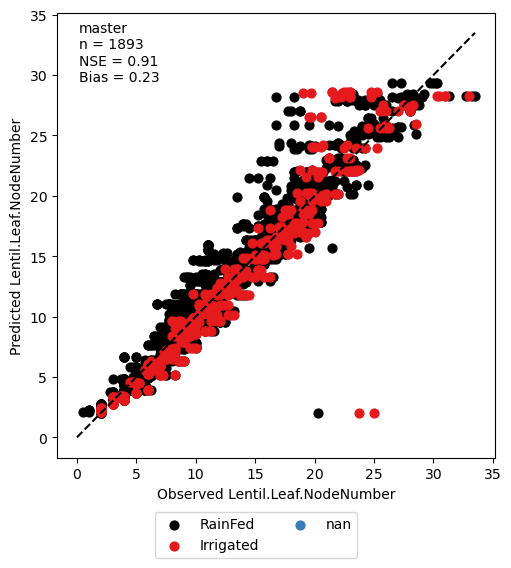

In [30]:
plot_obs_pred_by_branch("Lentil.Leaf.NodeNumber",demark_by='WaterTrt',mode='',
                       leg=True, leg_ncols = 2)

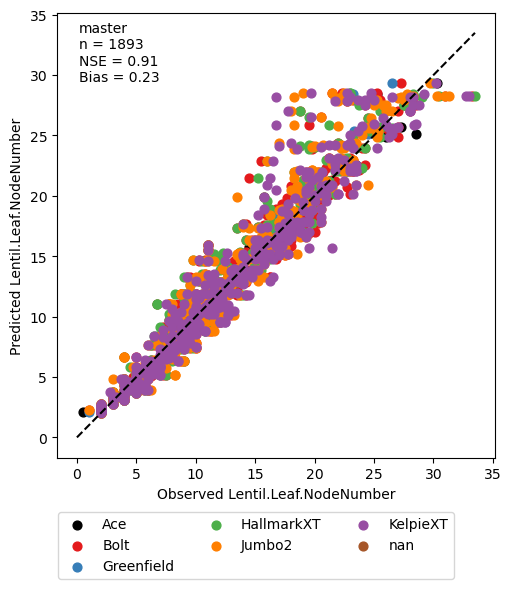

In [31]:
plot_obs_pred_by_branch("Lentil.Leaf.NodeNumber",demark_by='Lentil.SowingData.Cultivar',mode='',
                       leg=True, leg_ncols = 3)

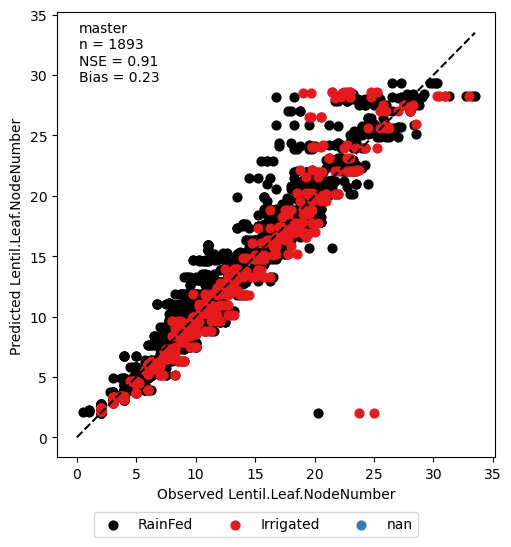

In [32]:
plot_obs_pred_by_branch("Lentil.Leaf.NodeNumber",demark_by='WaterTrt',mode='',
                       leg=True, leg_ncols = 3)

# Above ground wt

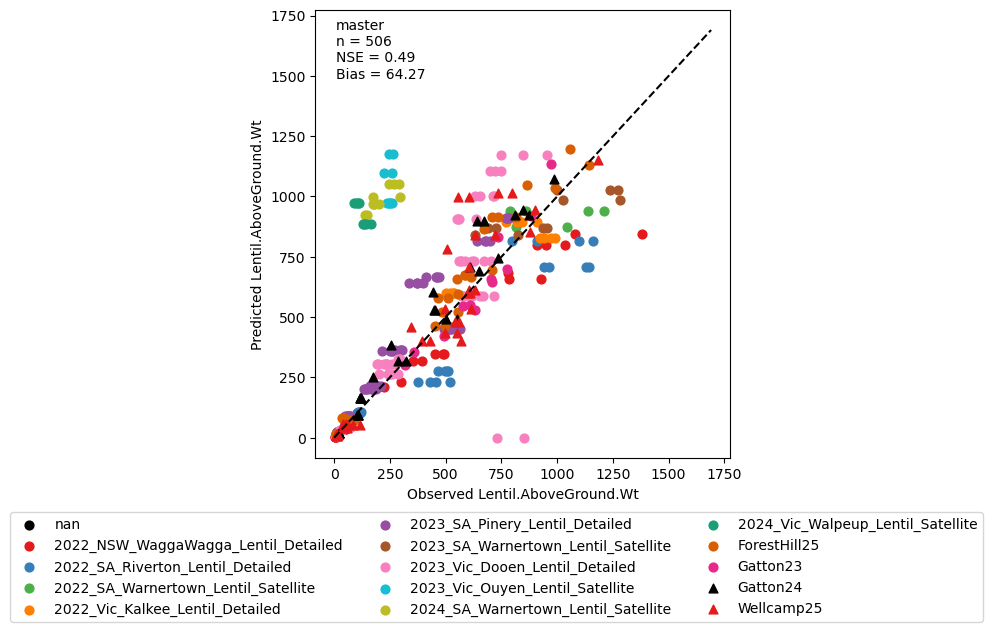

In [33]:
plot_obs_pred_by_branch("Lentil.AboveGround.Wt",demark_by='Experiment',mode='',
                       leg=True, leg_ncols = 3)

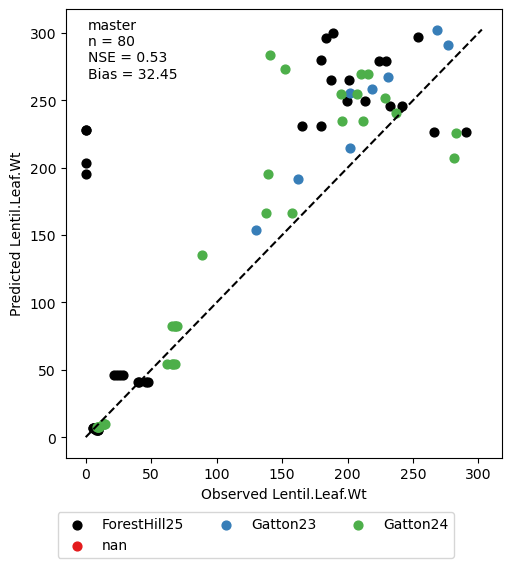

In [34]:
plot_obs_pred_by_branch("Lentil.Leaf.Wt",demark_by='Experiment',mode='',
                       leg=True, leg_ncols = 3)

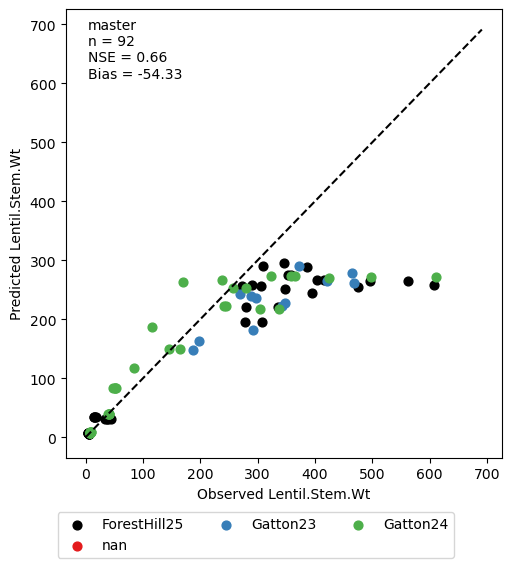

In [35]:
plot_obs_pred_by_branch("Lentil.Stem.Wt",demark_by='Experiment',mode='',
                       leg=True, leg_ncols = 3)

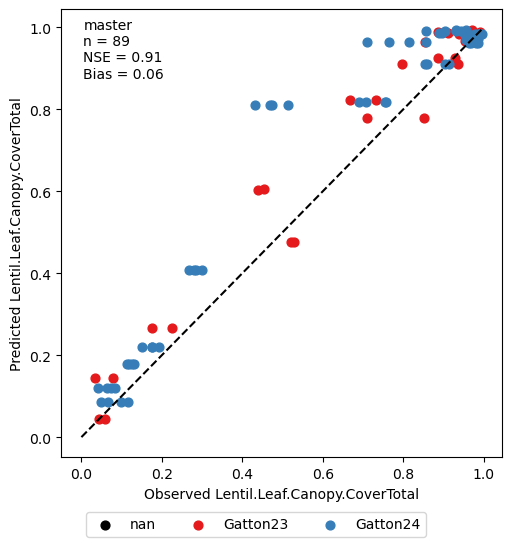

In [36]:
plot_obs_pred_by_branch('Lentil.Leaf.Canopy.CoverTotal',demark_by='Experiment',mode='',
                       leg=True, leg_ncols = 3)